In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [3]:
#Physical constants
sigma = 5.67e-8   #Stefan-Boltzmann constant (W/m^2/K^4)
h = 6.626e-34     #Planck's constant (J*s)
c = 3e8           #Speed of light (m/s)
k_B = 1.38e-23    #Boltzmann constant (J/K)
b = 2.898e-3      #Wien's displacement constant (m*K)
epsilon = 1.0     #Emissivity - perfect blackbody

# Temperatures to simulate
temperatures = [3000, 5000, 8000, 12000]  #Kelvin

# Wavelength range
wavelengths = np.linspace(1e-9, 3e-6, 1000)  #1nm to 3000nm

In [4]:
#Implimentation of Plancks law

def plancks_law(wavelength, temperature):
    exponent = (h * c) / (wavelength * k_B * temperature)
    # Avoid overflow by returning 0 where exponent is too large
    with np.errstate(over='ignore'):
        result = (2 * h * c**2) / (wavelength**5 * (np.exp(exponent) - 1))
    return np.where(exponent > 709, 0, result)

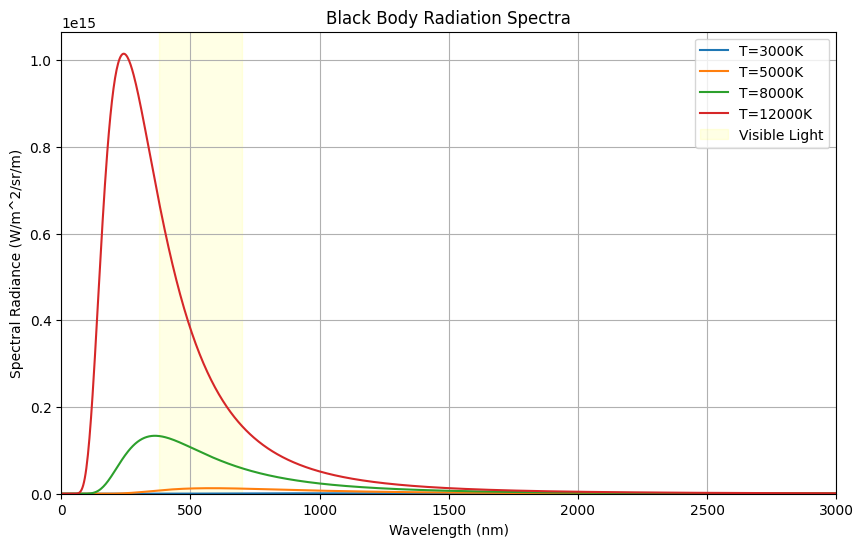

In [5]:
#Calculating spectral radiance for each temperature and plotting them
plt.figure(figsize=(10, 6))
for T in temperatures:
    spectral_radiance = plancks_law(wavelengths, T)
    plt.plot(wavelengths * 1e9, spectral_radiance, label=f'T={T}K')
plt.title('Black Body Radiation Spectra')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Radiance (W/m^2/sr/m)')
plt.xlim(0, 3000)
plt.ylim(0, None)
plt.axvspan(380, 700, alpha=0.1, color='yellow', label='Visible Light')
plt.legend()
plt.grid()
plt.show()

In [6]:
#Calculating Wien's displacement law for each temperature
wien_wavelengths = b / np.array(temperatures)
print("Wien's Displacement Law:")
for T, wl in zip(temperatures, wien_wavelengths):
    print(f'Temperature: {T} K, Peak Wavelength: {wl*1e9:.2f} nm')
    

Wien's Displacement Law:
Temperature: 3000 K, Peak Wavelength: 966.00 nm
Temperature: 5000 K, Peak Wavelength: 579.60 nm
Temperature: 8000 K, Peak Wavelength: 362.25 nm
Temperature: 12000 K, Peak Wavelength: 241.50 nm


In [7]:
for T in [3000, 5000, 8000, 12000]:
    M = epsilon * sigma * T**4
    print(f"T={T}K: {M:.2f} W/m²")

T=3000K: 4592700.00 W/m²
T=5000K: 35437500.00 W/m²
T=8000K: 232243200.00 W/m²
T=12000K: 1175731200.00 W/m²


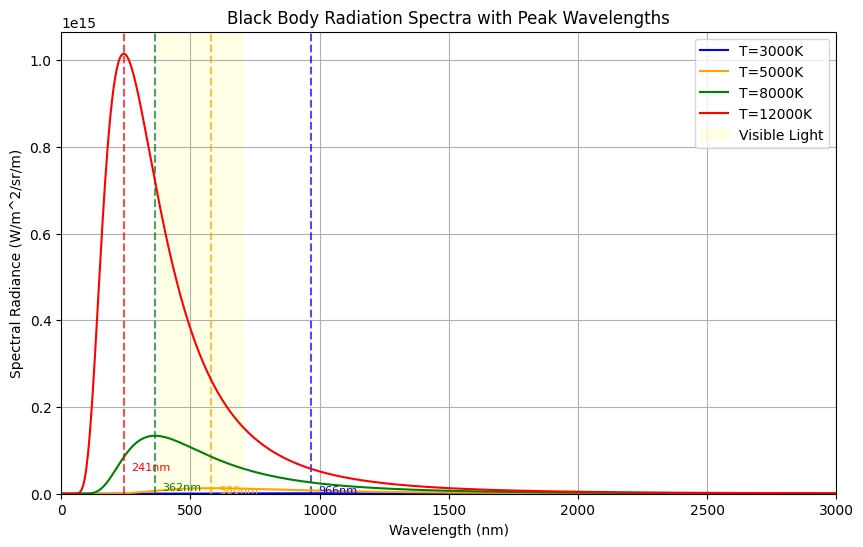

In [8]:
colors = ['blue', 'orange', 'green', 'red']

plt.figure(figsize=(10, 6))

for T, color in zip(temperatures, colors):
    spectral_radiance = plancks_law(wavelengths, T)
    plt.plot(wavelengths * 1e9, spectral_radiance,
             color=color, label=f'T={T}K')
    peak_wavelength = b / T
    plt.axvline(peak_wavelength * 1e9, color=color,
                linestyle='--', alpha=0.7)
    plt.annotate(f'{peak_wavelength*1e9:.0f}nm',
                 xy=(peak_wavelength * 1e9, 0),
                 xytext=(peak_wavelength * 1e9 + 30,
                         plt.gca().get_ylim()[1] * 0.05),
                 fontsize=8, color=color)

plt.axvspan(380, 700, alpha=0.1, color='yellow', label='Visible Light')
plt.title('Black Body Radiation Spectra with Peak Wavelengths')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Radiance (W/m^2/sr/m)')
plt.xlim(0, 3000)
plt.ylim(0, None)
plt.legend()
plt.grid()
plt.show()

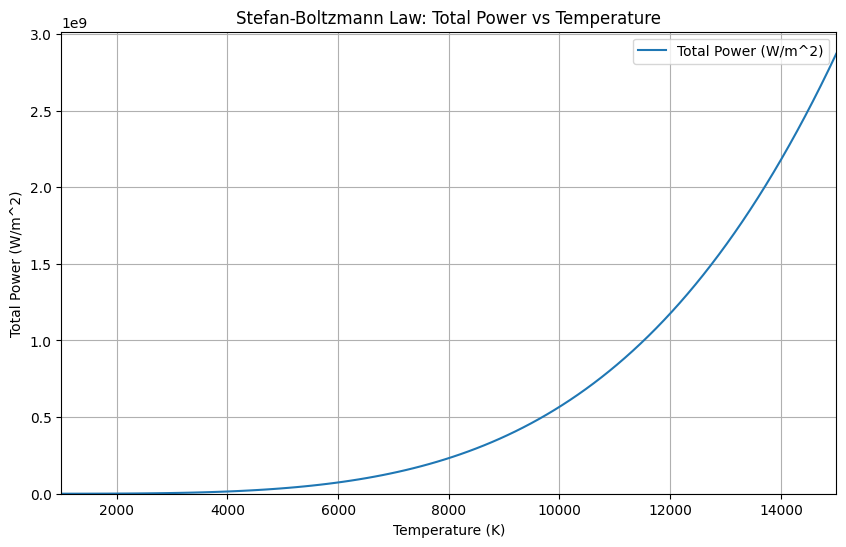

In [9]:
#Stefan-Boltzmann total power vs temperature.
temperatures_full = np.linspace(1000, 15000, 100)
total_power = epsilon * sigma * temperatures_full**4
plt.figure(figsize=(10, 6))
plt.plot(temperatures_full, total_power, label='Total Power (W/m^2)')
plt.title('Stefan-Boltzmann Law: Total Power vs Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('Total Power (W/m^2)')
plt.xlim(1000, 15000)
plt.ylim(0, None)
plt.legend()
plt.grid()
plt.show()